In [331]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

In [332]:
LEARNING_RATE = 0.001
BATCH_SIZE = 32
WEIGHT_DECAY = 0.0001
EPOCHS = 100
SEED = 42

In [333]:
TARGET_DIR = f"outputs/Mushuroom_Logistic/{WEIGHT_DECAY}/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"

In [334]:
def load_result(optimizer_name):
    file_path = f"{TARGET_DIR}/{optimizer_name}/result.json"
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} が見つかりません。空のリストを返します。")
        return [], [], [], [], []
    
    with open(file_path, "r") as f:
        data = json.load(f)
    
    return data["x"], data["train_loss"], data["train_acc"], data["test_loss"], data["test_acc"]

SGD_x, SGD_train_loss_history, SGD_train_acc_history, SGD_test_loss_history, SGD_test_acc_history = load_result("SGD")
SVRG_x, SVRG_train_loss_history, SVRG_train_acc_history, SVRG_test_loss_history, SVRG_test_acc_history = load_result("SVRG")
NFG_SVRG_x, NFG_SVRG_train_loss_history, NFG_SVRG_train_acc_history, NFG_SVRG_test_loss_history, NFG_SVRG_test_acc_history = load_result("NFG_SVRG")
ASAI_SVRG_x, ASAI_SVRG_train_loss_history, ASAI_SVRG_train_acc_history, ASAI_SVRG_test_loss_history, ASAI_SVRG_test_acc_history = load_result("ASAI_SVRG")
Polyak_SVRG_x, Polyak_SVRG_train_loss_history, Polyak_SVRG_train_acc_history, Polyak_SVRG_test_loss_history, Polyak_SVRG_test_acc_history = load_result("Polyak_SVRG")
_, GD_train_loss_history, GD_train_acc_history, GD_test_loss_history, GD_test_acc_history = load_result("GD")

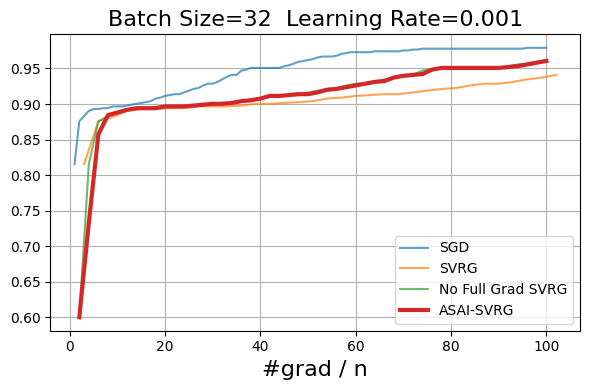

In [335]:
fig = plt.figure(figsize = (6, 4))
ax = fig.add_subplot()
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD", c = 'tab:blue', alpha = 0.7)
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG", c = 'tab:orange', alpha = 0.7)
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG", c = 'tab:green', alpha = 0.7)
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3, c = 'tab:red')
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

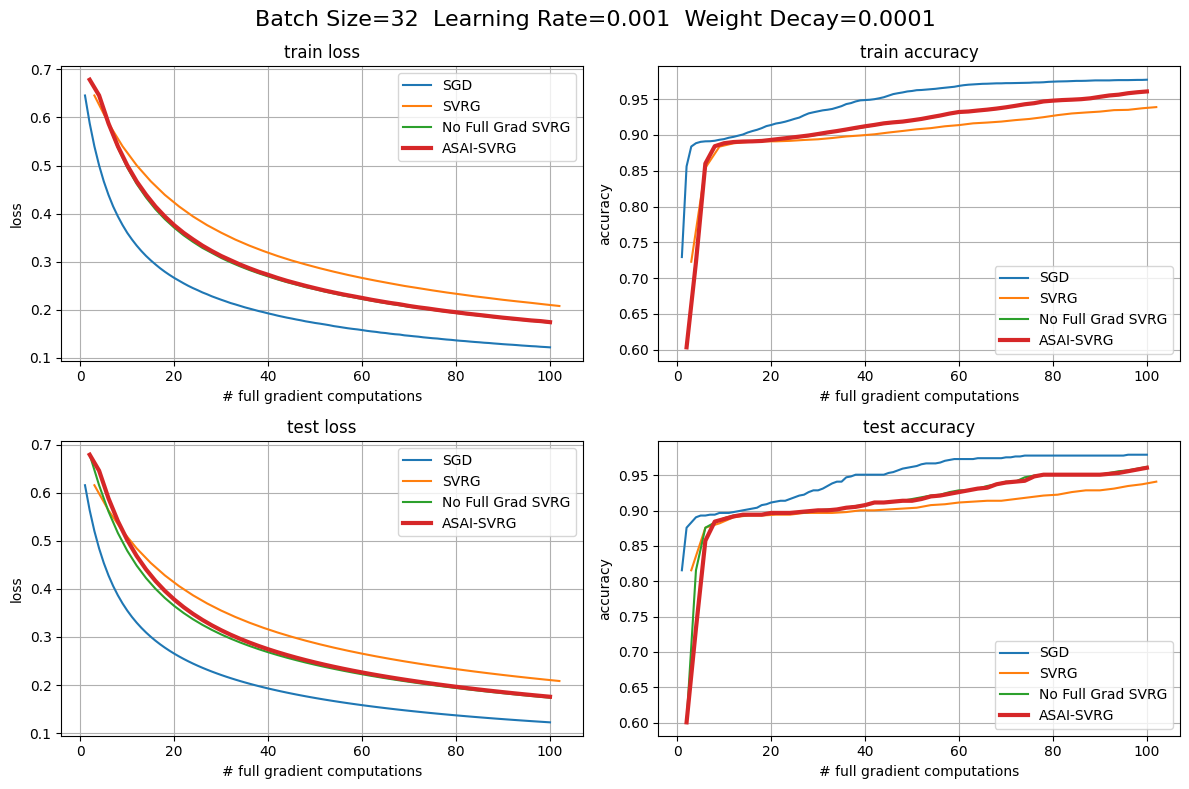

In [336]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}  Weight Decay={WEIGHT_DECAY}",fontsize=16)

ax = fig.add_subplot(2, 2, 1)
if SGD_x: ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_loss_history, label = "Polyak Full Grad SVRG")
if GD_train_loss_history: ax.plot(GD_train_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
if SGD_x: ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_acc_history, label = "Polyak Full Grad SVRG")
if GD_train_acc_history: ax.plot(GD_train_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
if SGD_x: ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_loss_history, label = "Polyak Full Grad SVRG")
if GD_test_loss_history: ax.plot(GD_test_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
if SGD_x: ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
if SVRG_x: ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
if NFG_SVRG_x: ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
if ASAI_SVRG_x: ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
if Polyak_SVRG_x: ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_acc_history, label = "Polyak Full Grad SVRG")
if GD_test_acc_history: ax.plot(GD_test_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()